In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size':14})
import matplotlib.colors as mcolors
from matplotlib.cm import GnBu, viridis

import sys
sys.path.insert(0, '/projects/b1094/jding/athena/vis/python')
import athena_read
import glob


In [23]:
## Snapshots registration
#sim_name = 'disk-jiaru8'
sim_name = 'disk-tilted27'
#sim_name = 'disk-sph26'
#path = '/scratch/phn2956/disk-sph26/'
path = '/scratch/phn2956/' + sim_name + '/'
snapshot_list = sorted(glob.glob(path+'disk.out1.*.athdf'))


# Plot snapshots over time

In [ ]:
## Plot density, v_r, and Mdot

snapshot_plot = snapshot_list[0:101:10] # snapshot_list[0:101:5]

norm   = mcolors.PowerNorm(gamma=1.5, vmin=0, vmax=len(snapshot_plot)-1)
colors = [GnBu(0.3 + 0.7 * norm(i)) for i in range(len(snapshot_plot))]

fig,axs = plt.subplots(3,1, figsize=(6,4),sharex=True,sharey=False)

for i, frame in enumerate(snapshot_plot):
    
    ath_data  = athena_read.athdf(frame,num_ghost=2,quantities=["rho", "vel1", "vel2", "vel3"])
    t_sim = ath_data['Time']
    #print('loading snapshot at t= %5.1f'%t_sim)
    
    #### Read Athena++ data: coordinates. ####
    # ath_data['x1f'] gives the list of cell face coordinates; 'x1v' gives volume-centered values
    rad_app = ath_data['x1v']
    theta_app = ath_data['x2v']
    phi_app = ath_data['x3v']
    d_rad = rad_app[1]-rad_app[0]
    d_theta = theta_app[1]-theta_app[0]
    d_phi = phi_app[1]-phi_app[0]

    rad_3d, theta_3d, phi_3d = np.meshgrid(rad_app, theta_app, phi_app, indexing='ij')
    
    #### Read Athena++ data: velocity field. ####    
    vx1 = np.swapaxes(ath_data['vel1'],0,2) # index convention: (r, theta, phi)
    vx2 = np.swapaxes(ath_data['vel2'],0,2)
    vx3 = np.swapaxes(ath_data['vel3'],0,2)
    den = np.swapaxes(ath_data['rho'],0,2)

    ## Sigma = surface integral of rho over a sphere (mass/dr) / (2pi*r)
    Sigma_integrand = den * rad_3d**2 * np.sin(theta_3d) * d_theta * d_phi
    # exclude ghost cells along theta,phi axes
    Sigma = np.sum(Sigma_integrand[:,2:-2,2:-2],axis=(1,2))/(2*np.pi*rad_app)
    # Sigma = den[:,22,4] # value at midplane at arbitrary phi
    
    ## Mdot = surface integral of rho*vx1 over a sphere (mass/dr)
    Mdot_integrand = den*vx1 *rad_3d**2 * np.sin(theta_3d) * d_theta * d_phi
    # exclude ghost cells along theta,phi axes
    Mdot = np.sum(Mdot_integrand[:,2:-2,2:-2],axis=(1,2))#/(2*np.pi*rad_app)

    ## mass-weighted v_R = Mdot / (2pi*r*Sigma)
    vR = Mdot / (Sigma * 2*np.pi*rad_app) 
    # vR = vx1[:,22,4] # value at midplane at arbitrary phi
    
    #### Plot
    
    current_color = colors[i]
    lw     = 1.0 + 1.5 * (i / len(snapshot_plot))
    zorder = i + 10 
    
    if t_sim== 0:
        kws = {'c': 'k', 'ls':':','lw': 1.5, 'label': r'initial' % t_sim, 'zorder': zorder}
    elif i == len(snapshot_plot) - 1:
        kws = {'c': '#084081', 'lw': 2.5, 'label': r'final' % t_sim, 'zorder': zorder + 100}
    else:
        kws = {'c': current_color, 'lw': lw, 'alpha': 0.6, 'zorder': zorder}
        
    axs[0].plot(rad_app,Sigma,**kws)
    axs[1].plot(rad_app,vR,**kws)
    axs[2].plot(rad_app,Mdot,**kws)

    
    
sm = plt.cm.ScalarMappable(cmap=GnBu, norm=plt.Normalize(vmin=0, vmax=t_sim))
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Time', fontsize=12)


#### Add analytical solutions
Sigma_sol = Sigma[-1] * (rad_app/rad_app[-1])**-1.5
vR_sol    = vR[-1] * (rad_app/rad_app[-1])**0.5
Mdot_sol  = Mdot[-1] * (rad_app/rad_app[-1])**0
axs[0].plot(rad_app,Sigma_sol,c='r',lw=1.5,ls='--',zorder=zorder+200)
axs[1].plot(rad_app,vR_sol,c='r',lw=1.5,ls='--',zorder=zorder+200)
axs[2].plot(rad_app,Mdot_sol,c='r',lw=1.5,ls='--',zorder=zorder+200)
axs[0].plot([],[],c='r',lw=1.5,ls='--',zorder=zorder+200,label='expect')

#### labels
axs[0].set_ylabel(r'$\Sigma$')
axs[1].set_ylabel(r'$v_{R}$')
axs[2].set_ylabel(r'$\dot{M}$')
axs[-1].set_xlabel(r'$R$')
#axs[-1].set_xlim(rad_app[[3,-4]])

# limits used in disk-sph plots
axs[0].set_ylim(0, .4)
axs[1].set_ylim(-1.5e-3, 1e-4)
axs[2].set_ylim(-8e-4, 5e-5)

# limits used for disk-jiaru plots
# axs[0].set_ylim(0, 1000) # 1000
# axs[1].set_ylim(-1.5e-2, 1e-2) # varying range
# axs[2].set_ylim(-10, 5) # varying range
# axs[0].set_ylim(0, 100) # original
# axs[1].set_ylim(-1.5e-3, 1e-4) # original
# axs[2].set_ylim(-8e-4, 5e-5) # original

axs[0].legend(
    fontsize=11,
    loc='lower left',        
    bbox_to_anchor=(0., 1.02, 1., .102), 
    ncol=3,                  
    mode="expand",          
    borderaxespad=0.1       
)


for ax in axs.flatten():
    ax.tick_params(which='both',direction='in')

save_fig = True
if save_fig:
    plt.savefig("Figs/" + sim_name + "-snapshots.png", bbox_inches='tight')


## plot $\rho(\vec{r})$

In [ ]:
snapshot_plot = snapshot_list[-2:-1:1] # snapshot_list[0:101:5]

for i, frame in enumerate(snapshot_plot):
    
    ath_data  = athena_read.athdf(frame,num_ghost=2,quantities=["rho", "vel1", "vel2", "vel3"])
    t_sim = ath_data['Time']
    #print('loading snapshot at t= %5.1f'%t_sim)
    
    #### Read Athena++ data: coordinates. ####
    rad_app = ath_data['x1f']
    theta_app = ath_data['x2f']
    phi_app = ath_data['x3f']
    d_rad = rad_app[1]-rad_app[0]
    d_theta = theta_app[1]-theta_app[0]
    d_phi = phi_app[1]-phi_app[0]
    
    rad_app = (rad_app[1:]+rad_app[:-1])*0.5
    theta_app = (theta_app[1:]+theta_app[:-1])*0.5
    phi_app = (phi_app[1:]+phi_app[:-1])*0.5
    rad_3d, theta_3d, phi_3d = np.meshgrid(rad_app, theta_app, phi_app, indexing='ij')
    
    #### Read Athena++ data: velosity field. ####    
    vx1 = np.swapaxes(ath_data['vel1'],0,2)
    vx2 = np.swapaxes(ath_data['vel2'],0,2)
    vx3 = np.swapaxes(ath_data['vel3'],0,2)
    den = np.swapaxes(ath_data['rho'],0,2)

    fig = plt.figure(figsize=(8,6))
    #ax = fig.add_subplot()
    ax = fig.add_subplot(projection='polar')
    
    ## view from above
    #theta_ind = 23 # 27 = midplane of domain
    #c = ax.pcolormesh(phi_3d[:, theta_ind, :], rad_3d[:, theta_ind, :], den[:,theta_ind,:], cmap='viridis')
    
    ## view from the side
    phi_offset = 5
    phi_ind = 2 + phi_offset # phi~0
    phi_ind2 = (int) (len(phi_app) / 2) + phi_offset # phi~pi
    
    kws = {'cmap': 'viridis', 'norm': mcolors.LogNorm(vmin=1e-1, vmax=1e4)}
    ax.pcolormesh(theta_3d[:,:,phi_ind], rad_3d[:,:,phi_ind], den[:,:,phi_ind], **kws)
    # for phi \in (pi/2, 3pi/2), theta has to be measured in the opposite direction (so, 2pi-...)
    c = ax.pcolormesh(2*np.pi-theta_3d[:,:,phi_ind2], rad_3d[:,:,phi_ind2], den[:,:,phi_ind2], **kws)
    
    #cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
    fig.colorbar(c, ax=ax, label="den", pad=.1, fraction=0.02)
    
    ## in the below plot, the x-axis points right, the z-axis points up, and the y-axis
    # points into the page/screen
    # ax.set_rlim(.2, 2.2)
    ax.xaxis.set_label_position('top') 
    ax.set_xlabel("r", labelpad=-270)
    
    ax.set_thetalim(np.pi/2- .3, np.pi/2 + .3)
    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)
    ax.set_ylabel(r"$\theta$", labelpad=30)
    ax.yaxis.set_label_position("right")
    #ax.yaxis.tick_right()
    
    plt.title("t = {t_sim:.2f}".format(t_sim=t_sim), y=.9)
    
    save_fig = False
    if save_fig:
        plt.savefig("Figs/" + sim_name + "-rhos/" + "%05d"%i + ".png")

    #plt.close()
    
plt.show()

In [ ]:
phi_app

In [ ]:
fig = plt.figure(figsize=(8,6))
#ax = fig.add_subplot()
ax = fig.add_subplot(projection='polar')

## view from above
#theta_ind = 23 # 27 = midplane of domain
#c = ax.pcolormesh(phi_3d[:, theta_ind, :], rad_3d[:, theta_ind, :], den[:,theta_ind,:], cmap='viridis')

## view from the side
phi_offset = 0
phi_ind = 2 + phi_offset # phi~0
phi_ind2 = (int) (len(phi_app) / 2) + phi_offset # phi~pi

kws = {'cmap': 'viridis', 'norm': mcolors.LogNorm(vmin=1e-1, vmax=1e4)}
ax.pcolormesh(theta_3d[:,:,phi_ind], rad_3d[:,:,phi_ind], den[:,:,phi_ind], **kws)
# for phi \in (pi/2, 3pi/2), theta has to be measured in the opposite direction (so, 2pi-...)
c = ax.pcolormesh(2*np.pi-theta_3d[:,:,phi_ind2], rad_3d[:,:,phi_ind2], den[:,:,phi_ind2], **kws)

#cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(c, ax=ax, label="den", pad=.1, fraction=0.02)

## in the below plot, the x-axis points right, the z-axis points up, and the y-axis
# points into the page/screen
#ax.set_rlim(.4, 2.1)
ax.set_rlim(.4,.6) 
ax.xaxis.set_label_position('top') 
ax.set_xlabel("r", labelpad=-270)

ax.set_thetalim(np.pi/2- .3, np.pi/2 + .3)
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_ylabel(r"$\theta$", labelpad=30)
ax.yaxis.set_label_position("right")
#ax.yaxis.tick_right()

plt.title("t = {t_sim:.2f}".format(t_sim=t_sim), y=.9)

save_fig = False
if save_fig:
    plt.savefig("Figs/" + sim_name + "-rho.png")

plt.show()

In [ ]:
rad_3d[:,0,phi_ind]

In [ ]:
hist_path = "/scratch/phn2956/disk-tilted17/disk.hst"
hist = np.loadtxt(hist_path)

In [ ]:
hist[:,]

## plot $v_i(\vec{r})$

In [ ]:
vx1[:,-1,phi_ind]

In [ ]:
np.max(np.abs(vx3[:,:,phi_ind]))

In [ ]:
fig = plt.figure(figsize=(8,6))
#ax = fig.add_subplot()
ax = fig.add_subplot(projection='polar')

## view from the side
phi_ind_offset = 0
phi_ind = 2 + phi_ind_offset # phi~0
phi_ind2 = (int) (len(phi_app) / 2) + phi_ind_offset # phi~pi

kws = {'cmap': 'viridis'}#, 'norm': mcolors.LogNorm(vmin=1e-2, vmax=10)}
ax.pcolormesh(theta_3d[:,:,phi_ind], rad_3d[:,:,phi_ind], vx1[:,:,phi_ind], **kws)
# for phi \in (pi/2, 3pi/2), theta has to be measured in the opposite direction (so, 2pi-...)
c = ax.pcolormesh(2*np.pi-theta_3d[:,:,phi_ind2], rad_3d[:,:,phi_ind2], vx1[:,:,phi_ind2], **kws)

#cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(c, ax=ax, label="vx1", pad=.1, fraction=0.02)

## in the below plot, the x-axis points right, the z-axis points up, and the y-axis
# points into the page/screen
#ax.set_rlim(.45,.55)
#ax.set_rlim(.4, 2.1)
ax.xaxis.set_label_position('top') 
ax.set_xlabel("r", labelpad=-270)

#ax.set_thetalim(np.pi/2- .35, np.pi/2 + .35)
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_ylabel(r"$\theta$", labelpad=30)
ax.yaxis.set_label_position("right")
#ax.yaxis.tick_right()

plt.title("t = {t_sim:.2f}".format(t_sim=t_sim), y=.9)

save_fig = False
if save_fig:
    plt.savefig("Figs/" + sim_name + "-vx1.png")

plt.show()

## print slopes of profiles

The slopes should be $\Sigma \propto R^{-1.5}, v_R \propto R^{0.5},$ and $\dot{M} \propto R^{0}$.

In [ ]:
# indices of the two points we use to find the slope
i1 = 9
i2 = 17

slope = (np.log(Sigma[i2]) - np.log(Sigma[i1])) / \
    (np.log(rad_app[i2]) - np.log(rad_app[i1]))
print("Sigma slope=", np.round(slope,3))

vR_abs = np.abs(vR)
slope = (np.log(vR_abs[i2]) - np.log(vR_abs[i1])) / \
    (np.log(rad_app[i2]) - np.log(rad_app[i1]))
print("vR slope=", np.round(slope,3))

Mdot_abs = np.abs(Mdot)
slope = (np.log(Mdot_abs[i2]) - np.log(Mdot_abs[i1])) / \
    (np.log(rad_app[i2]) - np.log(rad_app[i1]))
print("Mdot slope=", np.round(slope,3))

# plot $\beta(R)$

Given the total angular momentum vector $\vec{L}(R)$, the inclination $\beta$ is defined via $\hat{L} = \langle \cos \gamma \sin \beta, \sin \gamma \sin \beta, \cos \beta \rangle$. Here, I calculate $\beta$ by taking the inverse cosine of the z-component of $\hat{L}$.

## helper functions

In [21]:
## helper functions
def SphToCart(r, theta, phi):
    '''
    Given spherical coordinates r, theta, and phi, return the Cartesian
    coordinates x, y, and z.
    
    '''

    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)

    return x, y, z

def VelSphToCart(theta, phi, vr, vtheta, vphi):
    '''
    Given spherical coordinates (theta,phi) and the velocity components
    in spherical coordinates, return the velocity components in 
    Cartesian coordinates.

    '''

    rHat = [np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)]
    thetaHat = [np.cos(theta)*np.cos(phi), np.cos(theta)*np.sin(phi), -np.sin(theta)]
    phiHat = [-np.sin(phi), np.cos(phi), 0]

    vx = vr*rHat[0] + vtheta*thetaHat[0] + vphi*phiHat[0]
    vy = vr*rHat[1] + vtheta*thetaHat[1] + vphi*phiHat[1]
    vz = vr*rHat[2] + vtheta*thetaHat[2] + vphi*phiHat[2]

    return vx, vy, vz

def calculateBetaR(rs, thetas, phis, dens, vrs, vthetas, vphis):
    '''
    Given the 3D coordinate grids (rs, thetas, phis), the 3D density data array,
    and the (spherical) velocity component data arrays, return beta(R).

    Assumes that all the input arrays include all the ghost cells.
    
    '''

    # assumes uniformaly spaced grid
    dr = rs[1,0,0] - rs[0,0,0]
    dtheta = thetas[0,1,0] - thetas[0,0,0]
    dphi = phis[0,0,1] - phis[0,0,0]

    # Cartesian coordinates
    xs, ys, zs = SphToCart(rs, thetas, phis)
    vxs, vys, vzs = VelSphToCart(thetas, phis, vrs, vthetas, vphis)
    
    dVs = rs*rs * np.sin(thetas) * dr * dtheta * dphi
    Lxs = dens*dVs * (ys*vzs - zs*vys)
    Lys = dens*dVs * (zs*vxs - xs*vzs)
    Lzs = dens*dVs * (xs*vys - ys*vxs)

    # integrate over theta,phi
    # exclude ghost cells along theta,phi axes
    Lx_R = np.sum(Lxs[:,2:-2,2:-2],axis=(1,2))
    Ly_R = np.sum(Lys[:,2:-2,2:-2],axis=(1,2))
    Lz_R = np.sum(Lzs[:,2:-2,2:-2],axis=(1,2))

    Lz_hats = Lz_R / np.sqrt(Lx_R*Lx_R + Ly_R*Ly_R + Lz_R*Lz_R)

    #print("Lz_hats:", Lz_hats)
    return np.arccos(Lz_hats)

## plotting cell

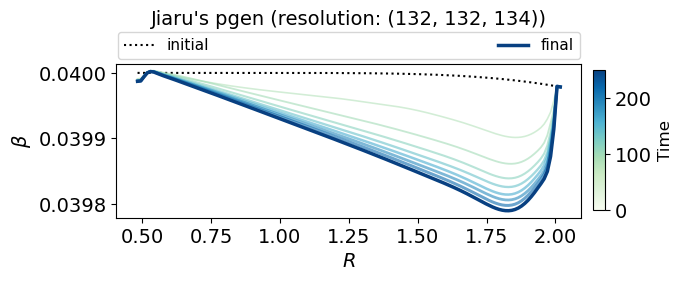

In [24]:
## Plot density, v_r, and Mdot

snapshot_plot = snapshot_list[0:101:10] # snapshot_list[0:101:5]

norm   = mcolors.PowerNorm(gamma=1.5, vmin=0, vmax=len(snapshot_plot)-1)
colors = [GnBu(0.3 + 0.7 * norm(i)) for i in range(len(snapshot_plot))]

fig,axs = plt.subplots(1,1, figsize=(6,2),sharex=True,sharey=False)

for i, frame in enumerate(snapshot_plot):
    ath_data  = athena_read.athdf(frame,num_ghost=2,quantities=["rho", "vel1", "vel2", "vel3"])
    t_sim = ath_data['Time']
    #print('loading snapshot at t= %5.1f'%t_sim)
    
    #### Read Athena++ data: coordinates. ####
    rad_app = ath_data['x1v']
    theta_app = ath_data['x2v']
    phi_app = ath_data['x3v']

    rad_3d, theta_3d, phi_3d = np.meshgrid(rad_app, theta_app, phi_app, indexing='ij')
    
    #### Read Athena++ data: velocity field. ####    
    vx1 = np.swapaxes(ath_data['vel1'],0,2) # index convention: (r, theta, phi)
    vx2 = np.swapaxes(ath_data['vel2'],0,2)
    vx3 = np.swapaxes(ath_data['vel3'],0,2)
    den = np.swapaxes(ath_data['rho'],0,2)

    betas = calculateBetaR(rad_3d, theta_3d, phi_3d, den, vx1, vx2, vx3)
    
    #### Plot
    
    current_color = colors[i]
    lw     = 1.0 + 1.5 * (i / len(snapshot_plot))
    zorder = i + 10 
    
    if t_sim== 0:
        kws = {'color': 'k', 'ls':':','lw': 1.5, 'label': r'initial' % t_sim, 'zorder': zorder}
    elif i == len(snapshot_plot) - 1:
        kws = {'color': '#084081', 'lw': 2.5, 'label': r'final' % t_sim, 'zorder': zorder + 100}
    else:
        kws = {'color': current_color, 'lw': lw, 'alpha': 0.6, 'zorder': zorder}
        
    axs.plot(rad_app,betas,**kws)
    
sm = plt.cm.ScalarMappable(cmap=GnBu, norm=plt.Normalize(vmin=0, vmax=t_sim))
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Time', fontsize=12)

#### labels
axs.set_ylabel(r'$\beta$')
axs.set_xlabel(r'$R$')
#axs.set_xlim(rad_app[[2,-2]])
#axs.set_ylim(0, 0.042)

axs.legend(
    fontsize=11,
    loc='lower left',        
    bbox_to_anchor=(0., 1.02, 1., .102), 
    ncol=3,                  
    mode="expand",          
    borderaxespad=0.1       
)

axs.set_title("Jiaru's pgen (resolution: " + str(rad_3d.shape) + ")", y=1.2, fontsize=14)

# for ax in axs.flatten():
#     ax.tick_params(which='both',direction='in')

save_fig = False
if save_fig:
    plt.savefig("Figs/" + sim_name + "-beta.png", bbox_inches='tight')


# plot $\rho(\vec{r})$ in 3D

In [ ]:
# should allow matplotlib plots to be interactive
# doesn't work in JupyterLab
use_interactive_plots = False
if use_interactive_plots:
    %matplotlib notebook

/home/phn2956/.conda/envs/jupyter-kernel-warps/lib/python3.12/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


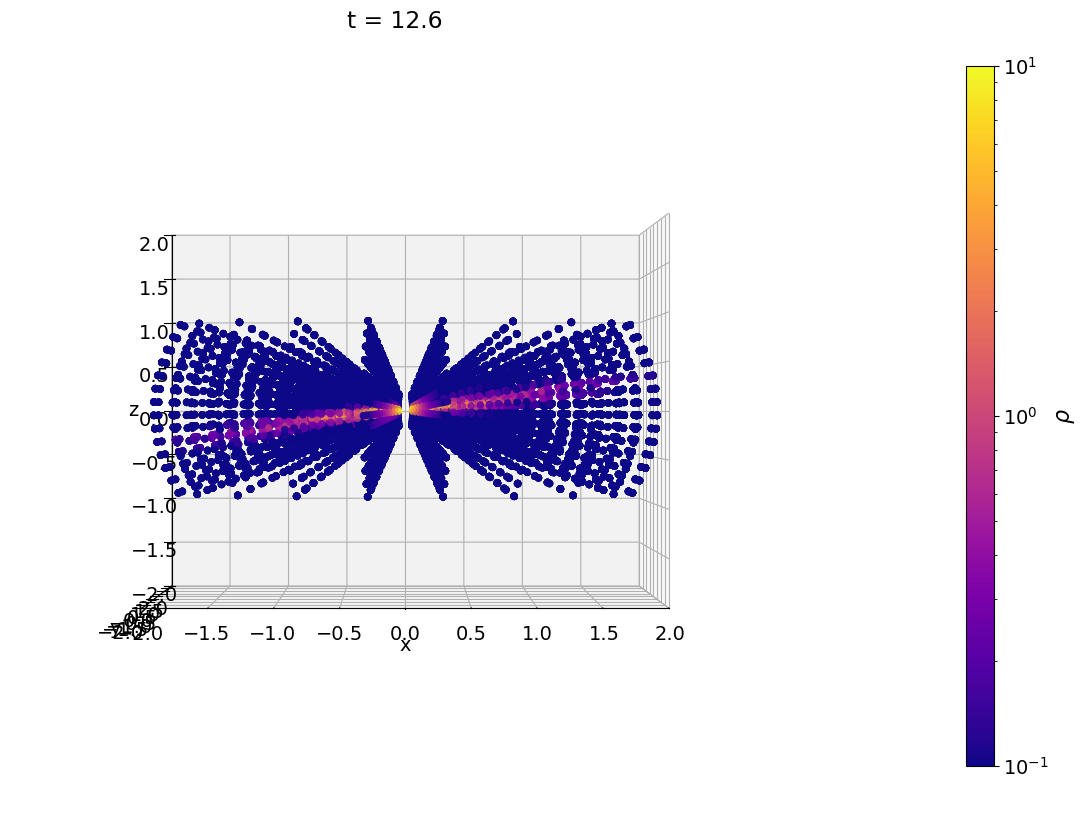

In [19]:
from matplotlib.animation import FuncAnimation

snapshot_plot = snapshot_list[0:10:1] # snapshot_list[0:101:5]
s1 = slice(0,None,2)
s2 = slice(0,None,7)
s3 = slice(0,None,1)

# 2. Set Up the Figure and 3D Axis
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Configure axis limits and aesthetics
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
ax.set_zlim([-2, 2])
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
#ax.set_facecolor('black') # Space theme
#fig.patch.set_facecolor('black')
#ax.xaxis.label.set_color('white')
#ax.yaxis.label.set_color('white')
#ax.zaxis.label.set_color('white')
#ax.tick_params(colors='white')

# Initialize the Plot
frame = snapshot_plot[0]
ath_data  = athena_read.athdf(frame,num_ghost=2,quantities=["rho", "vel1", "vel2", "vel3"])
t_sim = ath_data['Time']
ax.set_title("t = " + str(np.round(t_sim,1)))

rad_app = ath_data['x1v']
theta_app = ath_data['x2v']
phi_app = ath_data['x3v']
rad_3d, theta_3d, phi_3d = np.meshgrid(rad_app, theta_app, phi_app, indexing='ij')
den = np.swapaxes(ath_data['rho'],0,2)

rad_3d = rad_3d[s1, s2, s3]
theta_3d = theta_3d[s1, s2, s3]
phi_3d = phi_3d[s1, s2, s3]
den = den[s1, s2, s3]

x_3d, y_3d, z_3d = SphToCart(rad_3d, theta_3d, phi_3d)
colors = den

kws = {'cmap': 'plasma', 'norm': mcolors.LogNorm(vmin=1e-1, vmax=1e1)}

scatter = ax.scatter(x_3d, y_3d, z_3d, c=colors, s=5, alpha=0.8, **kws)
sm = plt.cm.ScalarMappable(**kws)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(r'$\rho$', fontsize=16)

# Optional: Rotate the viewing angle slightly over time
ax.view_init(elev=0, azim=-90)

# 4. Define the Update Function for FuncAnimation
def update(i):
    # Fetch new data for the current frame

    frame = snapshot_plot[i]
    ath_data  = athena_read.athdf(frame,num_ghost=2,quantities=["rho"])
    den = np.swapaxes(ath_data['rho'],0,2)
    colors = den[s1, s2, s3]

    t_sim = ath_data['Time']
    ax.set_title("t = " + str(np.round(t_sim,1)))

    # Update density values
    ax.scatter(x_3d, y_3d, z_3d, c=colors, **kws)
    
    return scatter,

# 5. Create and Save the Animation
# blit=False is usually required for 3D plots in Matplotlib
ani = FuncAnimation(fig, update, \
    frames=np.arange(0, len(snapshot_list), 1), interval=50, blit=False)

# To save the animation as an MP4 (requires ffmpeg installed):
ani.save('Figs/' + sim_name + '.gif', writer='pillow', fps=4)
    
plt.show()

plt.close()

In [ ]:
temp = np.zeros((4,4,9))

s1 = slice(0,None,1)
s2 = slice(2,3,1)
s3 = slice(5,6,1)
temp[s1, s2, s3]

## Gemini example

In [ ]:
from matplotlib.animation import FuncAnimation

# 1. Generate Mock Astrophysical Disk Data
def get_disk_state(timestep, num_particles=100):
    """Generates dummy 3D coordinates for a rotating disk."""
    np.random.seed(42)
    # Radial distribution (denser in the center)
    r = np.random.exponential(scale=2.0, size=num_particles)
    theta = np.random.uniform(0, 2*np.pi, size=num_particles)
    
    # Introduce rotation based on timestep
    angular_velocity = 1.0 / (r + 0.1) # Keplerian-ish rotation
    theta += angular_velocity * timestep
    
    # Calculate X, Y, and a thin Z (thickness)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    z = np.random.normal(scale=0.2, size=num_particles) * (r / 5) 
    
    return x, y, z

# 2. Set Up the Figure and 3D Axis
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Configure axis limits and aesthetics
ax.set_xlim([-10, 10])
ax.set_ylim([-10, 10])
ax.set_zlim([-5, 5])
ax.set_title("Astrophysical Disk Evolution")
ax.set_xlabel("X (pc)")
ax.set_ylabel("Y (pc)")
ax.set_zlabel("Z (pc)")
ax.set_facecolor('black') # Space theme
fig.patch.set_facecolor('black')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.zaxis.label.set_color('white')
ax.tick_params(colors='white')

# 3. Initialize the Plot
x0, y0, z0 = get_disk_state(0)
# We map color to the radial distance for visual depth
colors = np.sqrt(x0**2 + y0**2) 
scatter = ax.scatter(x0, y0, z0, c=colors, cmap='magma', s=2, alpha=0.8)

# 4. Define the Update Function for FuncAnimation
def update(frame):
    # Fetch new data for the current frame
    x, y, z = get_disk_state(frame)
    
    # The crucial optimization: update _offsets3d directly
    scatter._offsets3d = (x, y, z)
    
    # Optional: Rotate the viewing angle slightly over time
    # ax.view_init(elev=20, azim=frame * 2)
    
    return scatter,

# 5. Create and Save the Animation
# blit=False is usually required for 3D plots in Matplotlib
ani = FuncAnimation(fig, update, frames=10, interval=50, blit=False)

# To save the animation as an MP4 (requires ffmpeg installed):
ani.save('Figs/ex_disk_evolution.gif', writer='pillow', fps=20)

plt.show()